In [4]:
import pandas as pd
import ast
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Laden des bereinigten Datensatzes
df = pd.read_csv('Urteile_Bereinigt.csv')

# 2. Filterung auf die Rechtsprechung des EuGH
df_eugh = df[df['Gericht'] == 'EuGH'].copy()

# 3. Rekonstruktion der Lemmata (Nomen) aus der CSV-Struktur
df_eugh['lemmata'] = df_eugh['Text_Nomen'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) and x.startswith('[') else x
)

# 4. Definition der Stoppwortliste für den explorativen Ansatz
# Ausgeschlossen werden prozessuale Standardtermini und technische Artefakte
eugh_stop_explorativ = [
    # Prozessuale Begriffe und Institutionen
    'urteil', 'rechtssache', 'gerichtshof', 'vorabentscheidung', 'schlussantrag',
    'generalanwalt', 'vorlageverfahren', 'tenor', 'entscheidung', 'rs', 'eu',
    
    # Zitierweise und strukturelle Begriffe
    'artikel', 'absatz', 'buchstabe', 'ziffer', 'nr', 'abl', 'eudgb', 'aeuv', 'ewg',
    
    # Formale Füllwörter und Hilfsverben (als Nomen klassifiziert)
    'sowie', 'beziehungsweise', 'mitgliedstaat', 'anhängig', 'feststellen',
    
    # Bereinigung technischer Fragmente (Regex-Reste)
    'durchf', 'beh', 'rde', 'versto', 'vom'
]

print(f"Datensatz erfolgreich geladen: {len(df_eugh)} EuGH-Urteile für die explorative Analyse.")

Datensatz erfolgreich geladen: 81 EuGH-Urteile für die explorative Analyse.


In [5]:
import re

def fix_spaced_text(text_list):
    """Repariert fehlerhafte Leerzeichen innerhalb von Wörtern (Spatium-Fehler)."""
    text = " ".join(text_list)
    # Entfernung von Leerzeichen zwischen einzelnen Buchstaben
    fixed = re.sub(r'(?<=[a-zA-Z])\s(?=[a-zA-Z])', '', text)
    # Bereinigung multipler Leerzeichen
    fixed = re.sub(r'\s+', ' ', fixed)
    return fixed

# Gruppierung und Zusammenfassung der Texte pro Kalenderjahr
df_yearly = df_eugh.groupby('Jahr')['lemmata'].apply(
    lambda x: [item for sublist in x for item in sublist]
).reset_index()

# Anwendung der Korrekturfunktion auf die aggregierten Texte
df_yearly['text_joined'] = df_yearly['lemmata'].apply(fix_spaced_text)

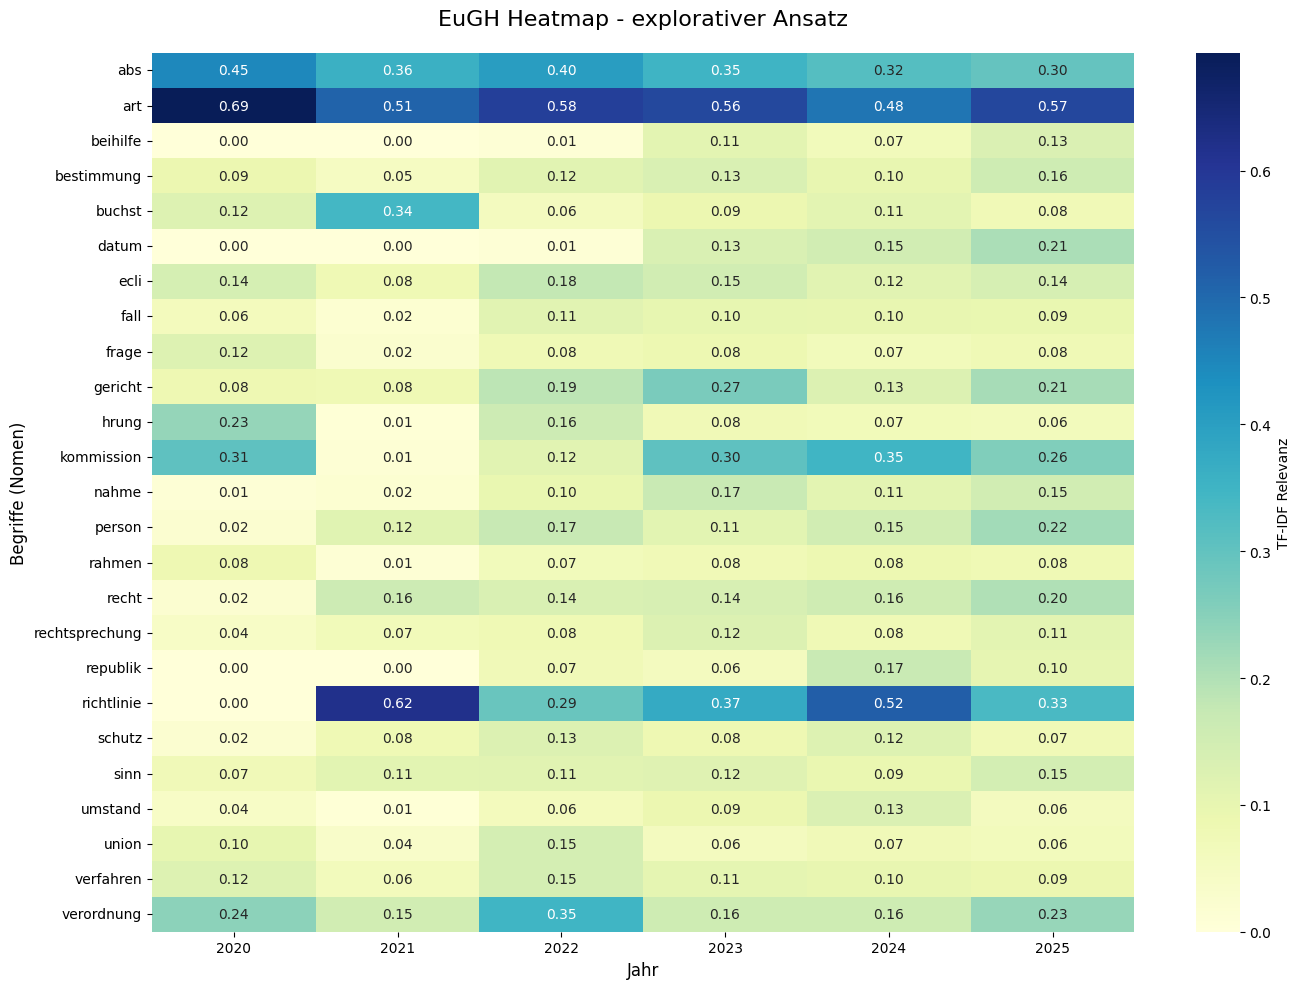

In [6]:
# 1. Konfiguration des TF-IDF Vektorisierers (Explorativer Ansatz)
tfidf_explorativ = TfidfVectorizer(
    stop_words=eugh_stop_explorativ, 
    max_df=1.0,                  # Berücksichtigung aller Termini außerhalb der Stoppwortliste
    min_df=1, 
    max_features=25,             # Beschränkung auf die Top 25 Merkmale
    token_pattern=r"(?u)\b\w\w\w+\b" # Filterung von Kurzwörtern (< 3 Zeichen)
)

# 2. Berechnung der TF-IDF Matrix
tfidf_matrix = tfidf_explorativ.fit_transform(df_yearly['text_joined'])

# 3. Überführung in ein DataFrame zur Visualisierung
heatmap_data = pd.DataFrame(
    tfidf_matrix.toarray(), 
    index=df_yearly['Jahr'], 
    columns=tfidf_explorativ.get_feature_names_out()
)

# 4. Erstellung der Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    heatmap_data.T, 
    annot=True, 
    fmt=".2f", 
    cmap='YlGnBu', 
    cbar_kws={'label': 'TF-IDF Relevanz'}
)

# Professionalisierung der Beschriftungen
plt.title('EuGH Heatmap - explorativer Ansatz', fontsize=16, pad=20)
plt.xlabel('Jahr', fontsize=12)
plt.ylabel('Begriffe (Nomen)', fontsize=12)
plt.tight_layout()

# Speicherung der Grafik für die Einbindung in das Textdokument
plt.savefig('EuGH_Heatmap_Explorativ.png', dpi=300)
plt.show()

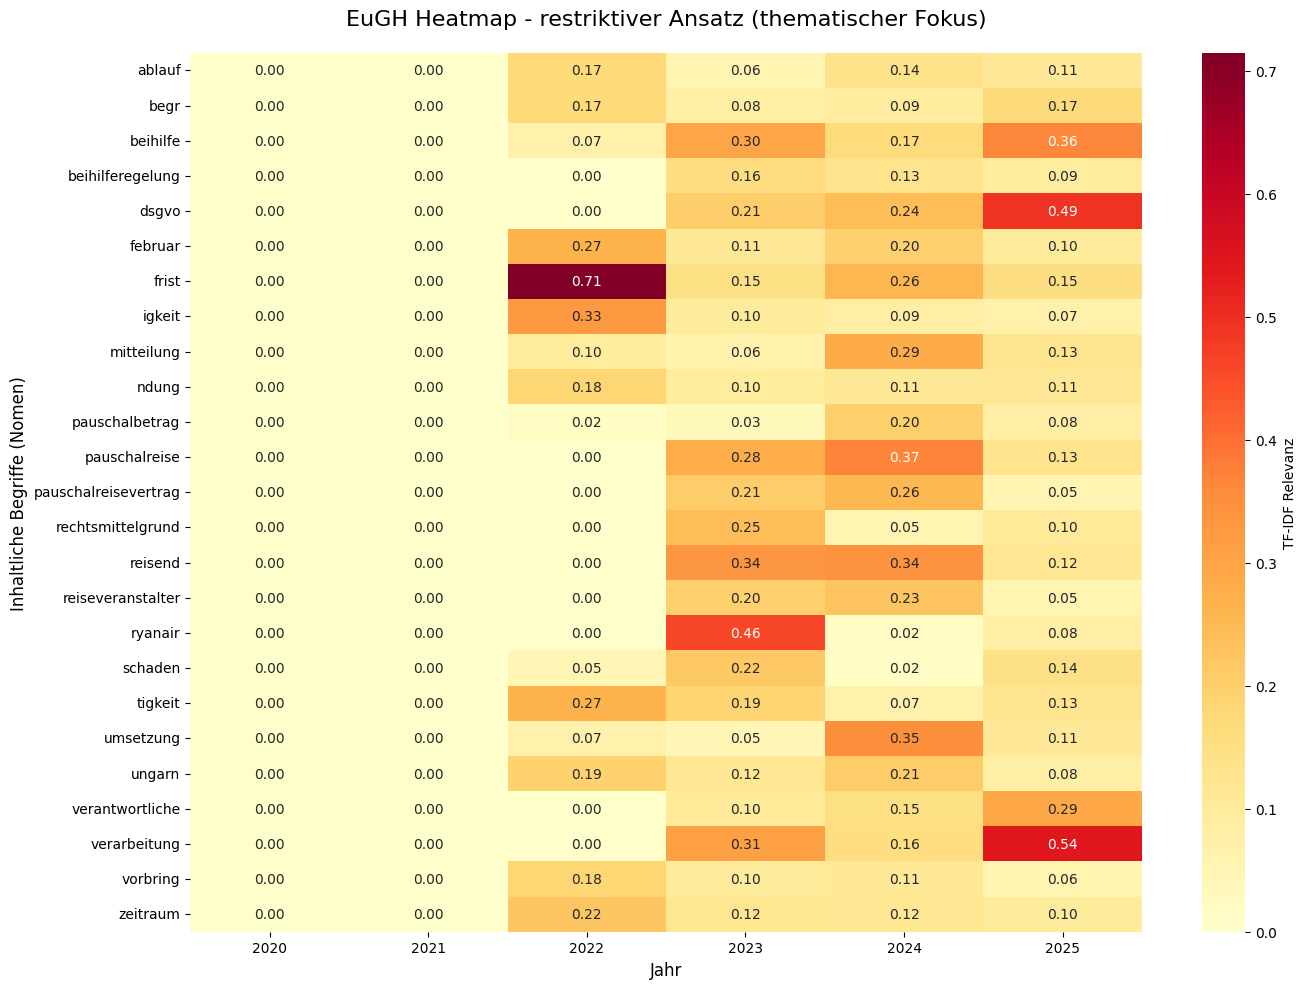

In [7]:
# Zelle 4: Heatmap - restriktiver Ansatz (Thematischer Fokus)

# Erweiterung der Stoppwortliste basierend auf der explorativen Analyse.
# Wir entfernen nun auch allgemeine Rechtsbegriffe und "leere" Nomen.
eugh_stop_restriktiv = eugh_stop_explorativ + [
    # Strukturelle Reste & Abkürzungen
    'abs', 'art', 'buchst', 'ecli', 'hrung', 'kommission', 'datum', 'nr', 'ziffer',
    
    # Allgemeine juristische Begriffe (Hintergrundrauschen)
    'fall', 'frage', 'gericht', 'person', 'rahmen', 'recht', 'rechtsprechung', 
    'republik', 'sinn', 'umstand', 'union', 'verfahren', 'nahmet', 'bestimmung',
    'jahr', 'tag', 'zeitpunkt', 'vorschrift', 'ziel', 'vertrag', 'verpflichtung', 
    'bereich', 'sache', 'voraussetzung', 'entscheidung', 'mitgliedstaat', 'anwendung'
]

# 1. Konfiguration des TF-IDF Vektorisierers (Restriktiver Ansatz)
tfidf_restriktiv = TfidfVectorizer(
    stop_words=eugh_stop_restriktiv, 
    max_df=0.8,                  # Filtere Begriffe, die in fast jedem Jahr vorkommen
    min_df=1, 
    max_features=25,             # Wir bleiben bei 25 für die Vergleichbarkeit
    token_pattern=r"(?u)\b\w\w\w+\b"
)

# 2. Berechnung der TF-IDF Matrix
tfidf_matrix_res = tfidf_restriktiv.fit_transform(df_yearly['text_joined'])

# 3. Überführung in ein DataFrame
heatmap_data_res = pd.DataFrame(
    tfidf_matrix_res.toarray(), 
    index=df_yearly['Jahr'], 
    columns=tfidf_restriktiv.get_feature_names_out()
)

# 4. Erstellung der Heatmap (Restriktiv)
plt.figure(figsize=(14, 10))
sns.heatmap(
    heatmap_data_res.T, 
    annot=True, 
    fmt=".2f", 
    cmap='YlOrRd', # 'YlOrRd' (Gelb-Orange-Rot) signalisiert optisch den inhaltlichen Fokus
    cbar_kws={'label': 'TF-IDF Relevanz'}
)

plt.title('EuGH Heatmap - restriktiver Ansatz (thematischer Fokus)', fontsize=16, pad=20)
plt.xlabel('Jahr', fontsize=12)
plt.ylabel('Inhaltliche Begriffe (Nomen)', fontsize=12)
plt.tight_layout()

# Speicherung für Word
plt.savefig('EuGH_Heatmap_Restriktiv.png', dpi=300)
plt.show()

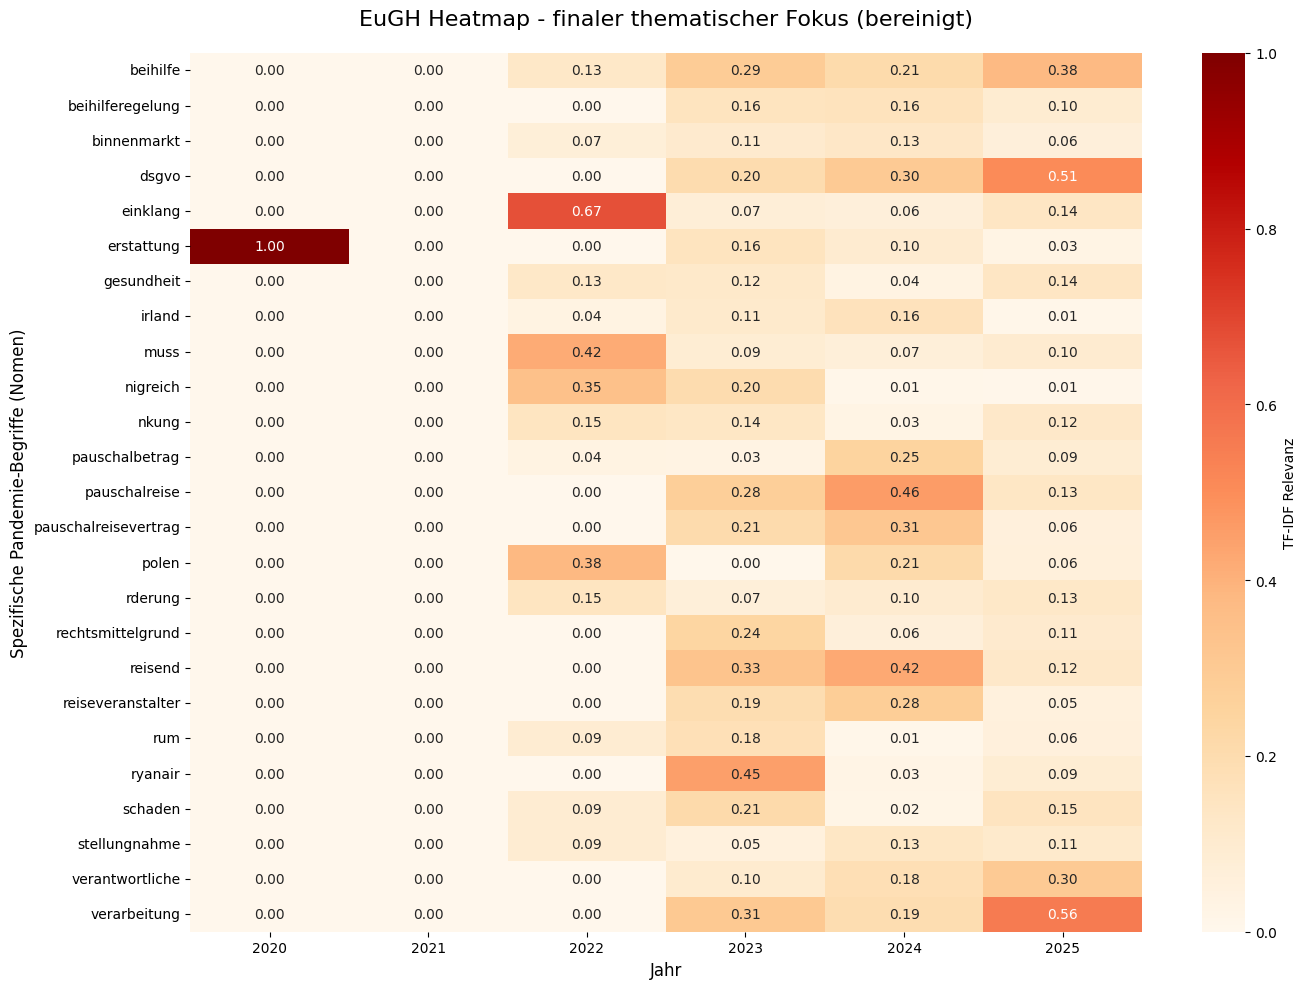

In [8]:
# Zelle 5: Heatmap - Finaler thematischer Fokus (Optimierte Filterung)

# Wir erweitern die Liste um die "Schattenbegriffe" aus dem zweiten Durchlauf
eugh_stop_final = eugh_stop_restriktiv + [
    'frist', 'begr', 'igkeit', 'ndung', 'vorbring', 'zeitraum', 
    'februar', 'umsetzung', 'tigkeit', 'tigkei', 'ablauf', 'mitteilung', 
    'ungarn', 'abschluss', 'vorliegen', 'vornahme', 'anhängigkeit'
]

# 1. Konfiguration des TF-IDF Vektorisierers
# Wir verschärfen max_df auf 0.7, um noch mehr "Dauerbrenner" zu eliminieren
tfidf_final = TfidfVectorizer(
    stop_words=eugh_stop_final, 
    max_df=0.7,                  
    min_df=1, 
    max_features=25,             
    token_pattern=r"(?u)\b\w\w\w+\b"
)

# 2. Berechnung der TF-IDF Matrix
tfidf_matrix_final = tfidf_final.fit_transform(df_yearly['text_joined'])

# 3. Überführung in ein DataFrame
heatmap_data_final = pd.DataFrame(
    tfidf_matrix_final.toarray(), 
    index=df_yearly['Jahr'], 
    columns=tfidf_final.get_feature_names_out()
)

# 4. Erstellung der Heatmap (Final)
plt.figure(figsize=(14, 10))
sns.heatmap(
    heatmap_data_final.T, 
    annot=True, 
    fmt=".2f", 
    cmap='OrRd', # Ein sattes Orange-Rot für das Endergebnis
    cbar_kws={'label': 'TF-IDF Relevanz'}
)

plt.title('EuGH Heatmap - finaler thematischer Fokus (bereinigt)', fontsize=16, pad=20)
plt.xlabel('Jahr', fontsize=12)
plt.ylabel('Spezifische Pandemie-Begriffe (Nomen)', fontsize=12)
plt.tight_layout()

# Speicherung für Word
plt.savefig('EuGH_Heatmap_Final.png', dpi=300)
plt.show()

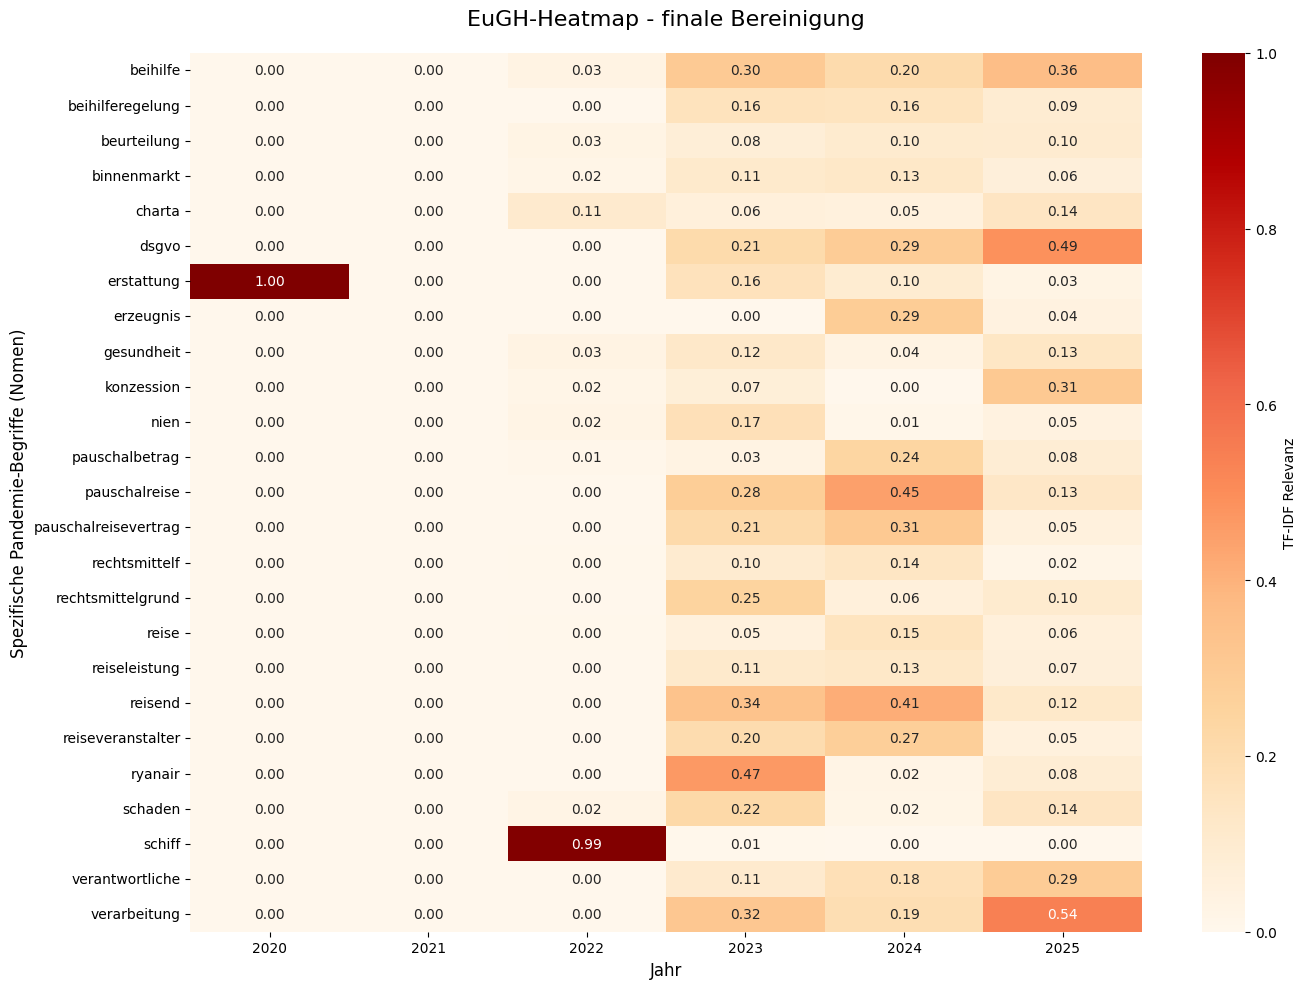

In [9]:
# Zelle 6: Heatmap - finale Bereinigung (Finales Endergebnis)

# Die endgültige Liste der Stoppwörter inkl. aller Iterationsschritte
eugh_stop_final_v3 = eugh_stop_final + [
    'muss', 'einklang', 'stellungnahme', 'nkung', 'rderung', 'rum', 
    'irland', 'polen', 'nigreich', 'erwägungsgrund', 'vorabentscheidungsersuchen'
]

# 1. Konfiguration des TF-IDF Vektorisierers
tfidf_final_v3 = TfidfVectorizer(
    stop_words=eugh_stop_final_v3, 
    max_df=0.7,                  
    min_df=1, 
    max_features=25,             
    token_pattern=r"(?u)\b\w\w\w+\b"
)

# 2. Berechnung der TF-IDF Matrix
tfidf_matrix_final_v3 = tfidf_final_v3.fit_transform(df_yearly['text_joined'])

# 3. Überführung in ein DataFrame
heatmap_data_final_v3 = pd.DataFrame(
    tfidf_matrix_final_v3.toarray(), 
    index=df_yearly['Jahr'], 
    columns=tfidf_final_v3.get_feature_names_out()
)

# 4. Erstellung der Heatmap (Finales Design)
plt.figure(figsize=(14, 10))
sns.heatmap(
    heatmap_data_final_v3.T, 
    annot=True, 
    fmt=".2f", 
    cmap='OrRd', 
    cbar_kws={'label': 'TF-IDF Relevanz'}
)

# Professionalisierte Überschrift
plt.title('EuGH-Heatmap - finale Bereinigung', fontsize=16, pad=20)
plt.xlabel('Jahr', fontsize=12)
plt.ylabel('Spezifische Pandemie-Begriffe (Nomen)', fontsize=12)
plt.tight_layout()

# Speicherung für die Einbindung in Word
plt.savefig('EuGH_Heatmap_Final_Bereinigt.png', dpi=300)
plt.show()

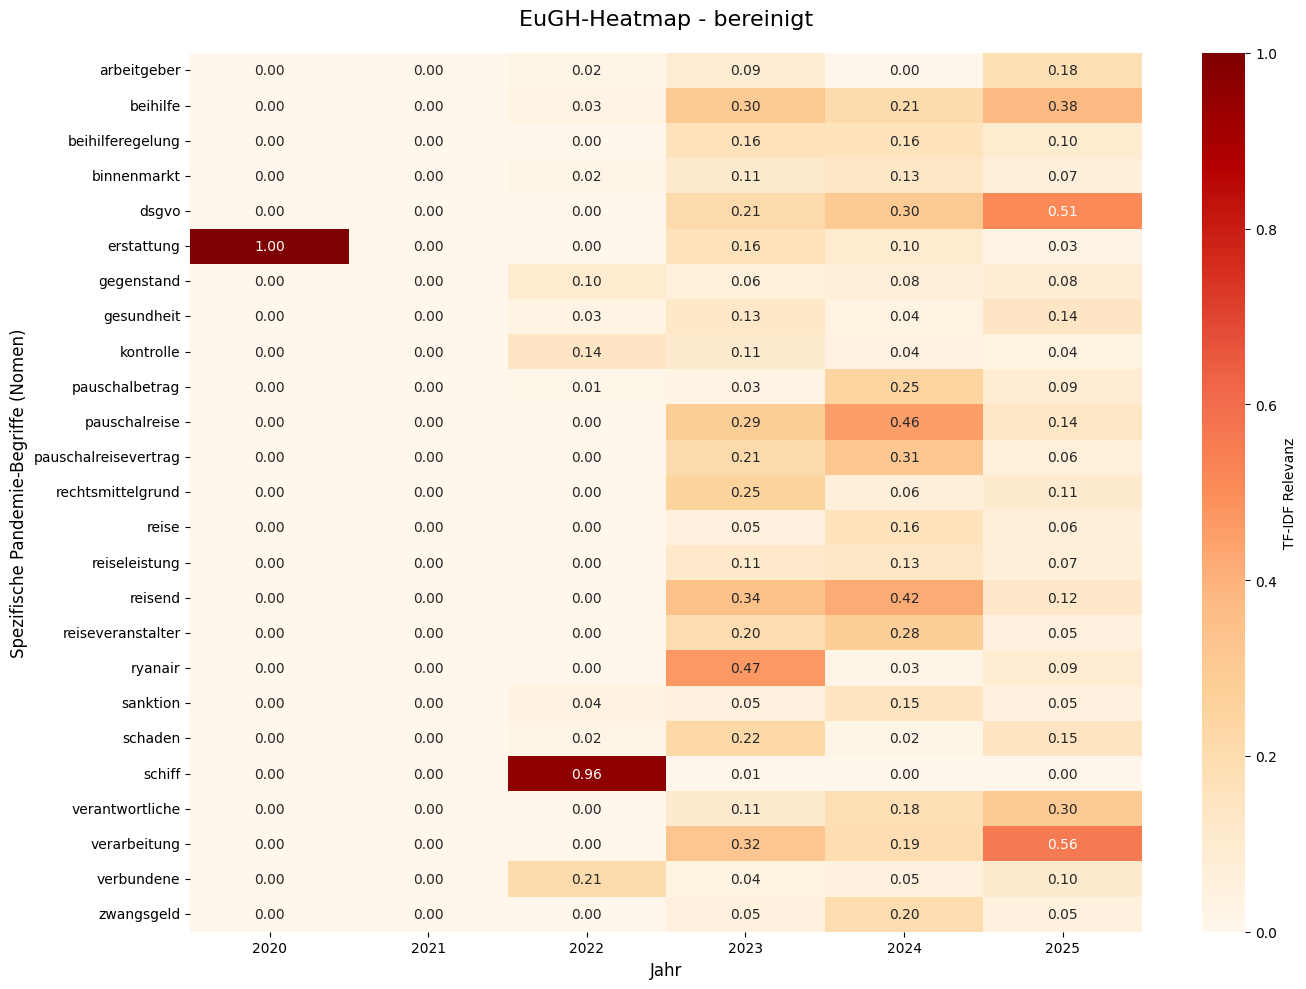

In [14]:
# Zelle 7: Finale Politur - Entfernung von Fragmenten und Rauschen (V2)

# Wir nehmen die bisherige Liste und fügen die letzten Störenfriede hinzu,
# inklusive des neu identifizierten Fragments "rechtsmittelf"
eugh_stop_final_v4 = eugh_stop_final_v3 + [
    'nien', 'muss', 'beurteilung', 'erzeugnis', 'konzession', 
    'charta', 'rechtsmittelf', 'vorbringung', 'bef', 'weise', 'rdigung'
]

# 1. Konfiguration des TF-IDF Vektorisierers (Finaler Schliff)
tfidf_final_v4 = TfidfVectorizer(
    stop_words=eugh_stop_final_v4, 
    max_df=0.7,                  
    min_df=1, 
    max_features=25,             
    token_pattern=r"(?u)\b\w\w\w+\b"
)

# 2. Berechnung der TF-IDF Matrix
tfidf_matrix_v4 = tfidf_final_v4.fit_transform(df_yearly['text_joined'])

# 3. Überführung in ein DataFrame
heatmap_data_v4 = pd.DataFrame(
    tfidf_matrix_v4.toarray(), 
    index=df_yearly['Jahr'], 
    columns=tfidf_final_v4.get_feature_names_out()
)

# 4. Visualisierung der finalen Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    heatmap_data_v4.T, 
    annot=True, 
    fmt=".2f", 
    cmap='OrRd', 
    cbar_kws={'label': 'TF-IDF Relevanz'}
)

plt.title('EuGH-Heatmap - bereinigt', fontsize=16, pad=20)
plt.xlabel('Jahr', fontsize=12)
plt.ylabel('Spezifische Pandemie-Begriffe (Nomen)', fontsize=12)
plt.tight_layout()

# Speicherung der optimierten Grafik
plt.savefig('EuGH_Heatmap_Version_Hausarbeit.png', dpi=300)
plt.show()